# Importing the necessary libraries

In [37]:
import os

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms

from Evaluator import Evaluator
from SegmentationModel import SegmentationModel
from Trainer import Trainer

# Parametri di configurazione

In [38]:
DATA_ROOT = 'train'
BATCH_SIZE = 4
LEARNING_RATE = 0.001
NUM_EPOCHS = 5
NUM_CLASSES = 9
MODEL_SAVE_PATH = 'saved_model.pth'

# Impostazione del device

In [39]:
if torch.cuda.is_available():
    device = torch.device('cuda')  # Configura per utilizzare la GPU
    print(f"Utilizzo GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')  # Fallback alla CPU
    print("CUDA non disponibile, utilizzo CPU")

Utilizzo GPU: NVIDIA GeForce RTX 5070 Ti


Numero di campioni nel dataset: 931


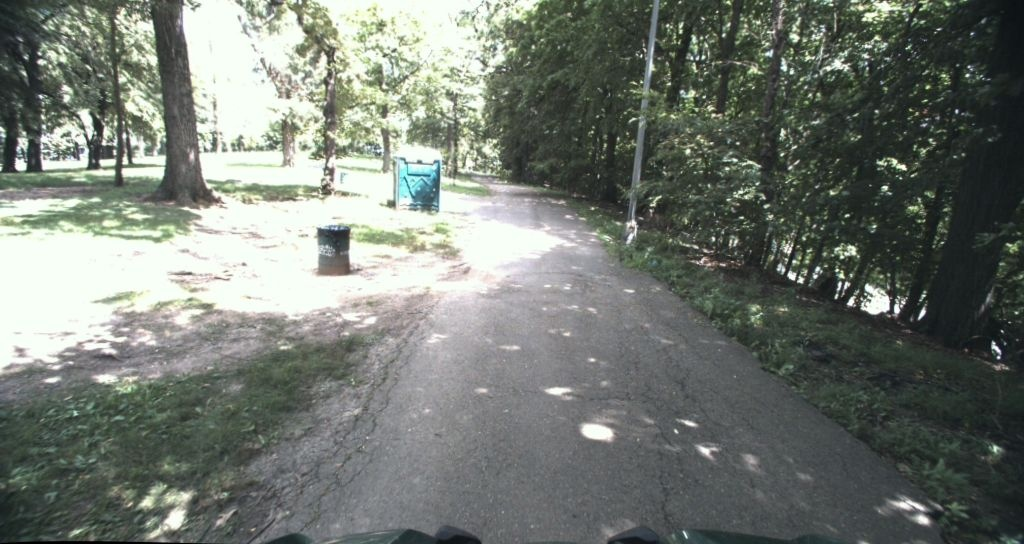

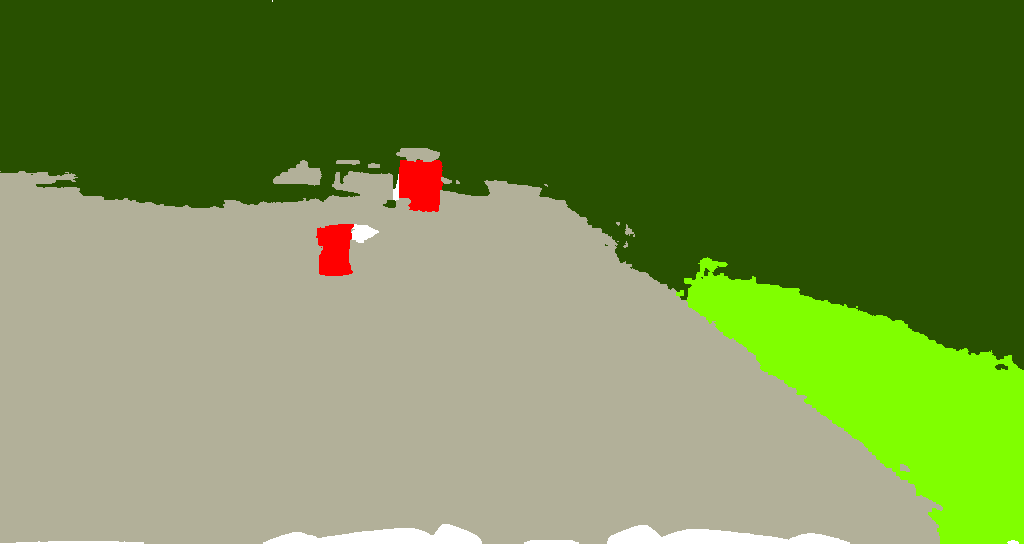

In [40]:
from RuralDataset import RuralDataset

dataset = RuralDataset("train")
print("Numero di campioni nel dataset:", len(dataset))
img1 = dataset.__getitem__(1)

## Inizializzazione Transform

In [41]:
transform = transforms.Compose([
        transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

full_dataset = RuralDataset(root_dir=DATA_ROOT, transform=transform)

# Divisione del dataset in training e validation

In [42]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count() // 2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count() // 2)

print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples.")

Training on 744 samples, validating on 187 samples.


# Inizializzazione del modello

In [43]:
model = SegmentationModel(num_classes=NUM_CLASSES).to(device)
print("Model architecture:")
print(model)

Model architecture:
SegmentationModel(
  (enc1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (enc2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dec1): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (dec2): Sequential(
    (0): ConvTranspose2d(32, 9, kernel_size=(2, 2), stride=(2, 2))
  )
)


## Definizione della funzione di loss e dell'ottimizzatore

In [44]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Inizializzazione e avvio del training

In [50]:
print(device)
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, device)
print("\nStarting training...")
trainer.run(num_epochs=NUM_EPOCHS, model_save_path=MODEL_SAVE_PATH)
print("Training finished.")

cuda

Starting training...
Epoch 1/5, Train Loss: 1.1688, Val IoU: 2.1637
Model saved! Best Val IoU: 2.1637
Epoch 2/5, Train Loss: 1.1406, Val IoU: 2.2654
Model saved! Best Val IoU: 2.2654
Epoch 3/5, Train Loss: 1.1231, Val IoU: 2.2632
Epoch 4/5, Train Loss: 1.1132, Val IoU: 2.2848
Model saved! Best Val IoU: 2.2848
Epoch 5/5, Train Loss: 1.1092, Val IoU: 2.2803
Training finished.


In [47]:
from PIL import Image

def draw_image_from_matrix(matrix):
    """
    Crea e mostra un'immagine da una matrice 2D di tuple RGB.

    :param matrix: Lista di liste contenenti tuple RGB [(R, G, B), ...]
                   Le dimensioni devono essere consistenti (rettangolare).
    """
    if not matrix or not matrix[0]:
        raise ValueError("La matrice non può essere vuota.")

    height = len(matrix)
    width = len(matrix[0])

    # Crea un'immagine RGB
    img = Image.new("RGB", (width, height))

    # Assegna i pixel
    for y in range(height):
        for x in range(width):
            img.putpixel((x, y), matrix[y][x])

    img.show()


import numpy as np

# Supponendo che preds[0] sia un array 2D con valori interi in [0, num_classi)
# E voglia assegnare colori RGB alle classi
def mask_to_rgb(mask):
    """
    Converte una maschera 2D in un'immagine RGB utilizzando una mappa di colori fissa.
    """
    color_map = [
        (0, 0, 0),        # classe 0 - nero
        (128, 0, 0),      # classe 1 - marrone scuro
        (0, 128, 0),      # classe 2 - verde scuro
        (128, 128, 0),    # classe 3 - oliva
        (0, 0, 128),      # classe 4 - blu scuro
        (128, 0, 128),    # classe 5 - viola
        (0, 128, 128),    # classe 6 - ciano scuro
        (128, 128, 128),  # classe 7 - grigio
        (255, 255, 255),  # classe 8 - bianco
    ]

    rgb_image = [[color_map[pixel] for pixel in row] for row in mask]
    return rgb_image

# Esegui il rendering della predizione
mask = labels[0].cpu().numpy()
rgb_matrix = mask_to_rgb(mask.astype(int))
draw_image_from_matrix(rgb_matrix)



# Valutazione finale del modello


Loading best model from saved_model.pth for final evaluation...
Final evaluation on validation set: Overall Mean IoU: 0.5743
La label visualizzata corrisponde al campione globale 5 del dataset.
Percorso file originale: ('train\\0005\\rgb.jpg', 'train\\0005\\labels.png')


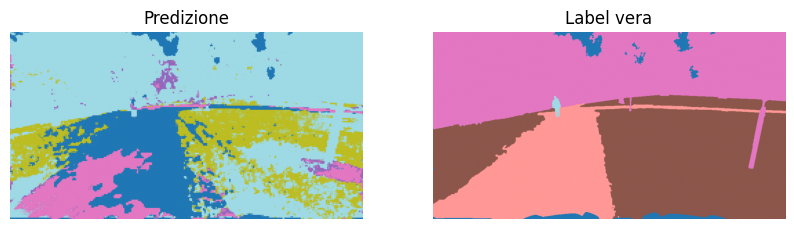

In [51]:
import matplotlib.pyplot as plt

if os.path.exists(MODEL_SAVE_PATH):
    print(f"\nLoading best model from {MODEL_SAVE_PATH} for final evaluation...")
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))

    final_evaluator = Evaluator(model, val_loader, device)
    overall_iou, iou_per_class = final_evaluator.evaluate()
    print(f"Final evaluation on validation set: Overall Mean IoU: {overall_iou:.4f}")

    # Ottieni un batch di immagini di validazione
    images, labels = next(iter(val_loader))
    images = images.to(device)
    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)  # (batch, H, W)

        # Trova l'indice globale della label visualizzata (es: indice 1 del batch)
        batch_index = 1
        global_index = val_dataset.indices[batch_index]
        # Recupera il path dal dataset originale
        sample_info = full_dataset.samples[global_index] if hasattr(full_dataset, "samples") else None
        print(f"La label visualizzata corrisponde al campione globale {global_index} del dataset.")
        if sample_info:
            print(f"Percorso file originale: {sample_info}")

        # Visualizza la prima immagine predetta e la label corrispondente
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.title("Predizione")
        plt.imshow(preds[batch_index].cpu().numpy(), cmap='tab20')
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.title("Label vera")
        plt.imshow(labels[batch_index].cpu().numpy(), cmap='tab20')
        plt.axis("off")
        plt.show()
else:
    print(f"No model found at {MODEL_SAVE_PATH}. Cannot perform final evaluation.")